In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix , classification_report

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [3]:
df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### 데이터 분석

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

### 데이터 분포 확인

C:\Users\최영준\AppData\Local\Temp\ipykernel_23252\2222293182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex',data=df , palette = 'bright')


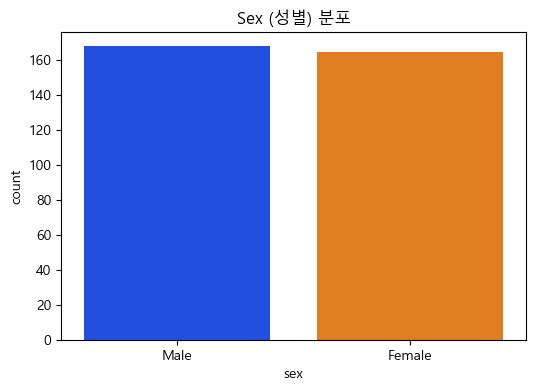

In [6]:
plt.figure(figsize = (6,4))
sns.countplot(x='sex',data=df , palette = 'bright')
plt.title('Sex (성별) 분포')
plt.show()

C:\Users\최영준\AppData\Local\Temp\ipykernel_23252\2870072193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species',data=df,palette = 'bright')


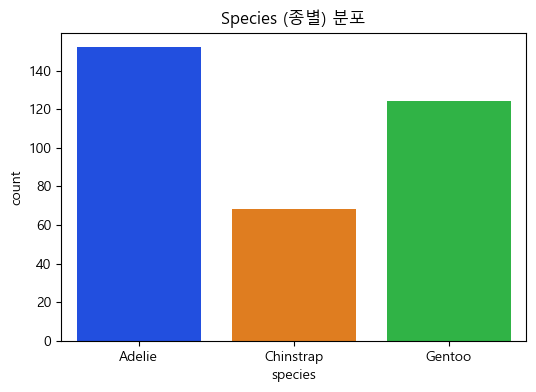

In [8]:
plt.figure(figsize = (6,4))
sns.countplot(x='species',data=df,palette = 'bright')
plt.title('Species (종별) 분포')
plt.show()

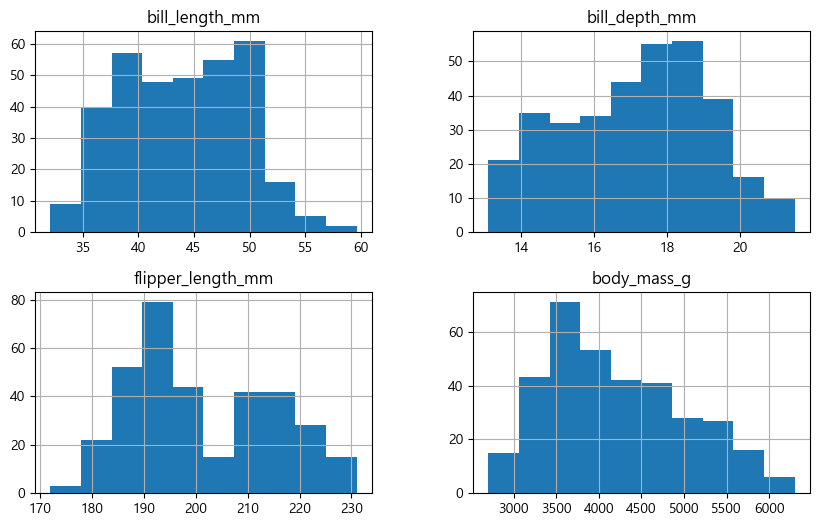

In [19]:
df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']].hist(figsize=(10,6))
plt.show()

- 표준화 스케일링 필요 

- 부리 길이와 부리 깊이의 종별 관계성 확인

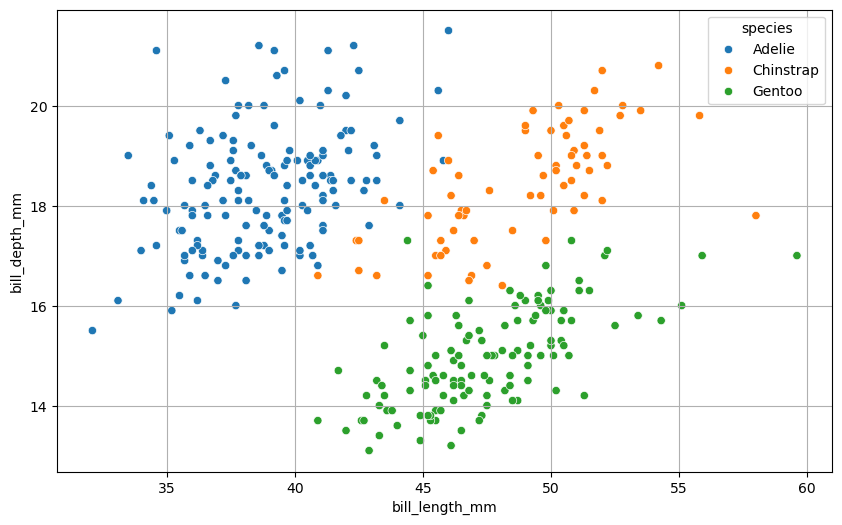

In [5]:
plt.figure(figsize = (10, 6))

sns.scatterplot(data = df, x='bill_length_mm', y='bill_depth_mm', hue = 'species')
plt.grid()
plt.show()

<Figure size 1000x600 with 0 Axes>

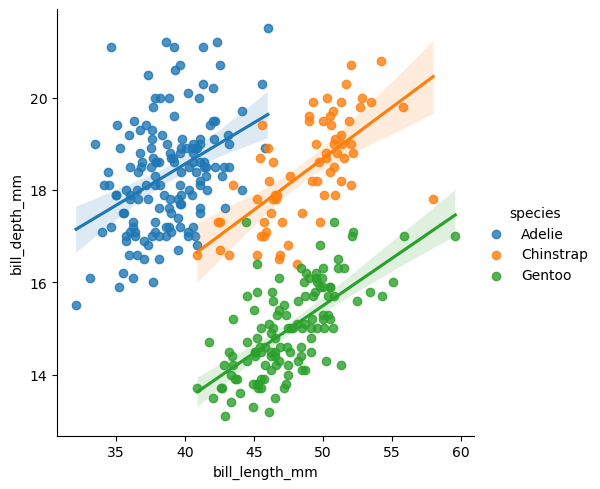

In [6]:
plt.figure(figsize = (10, 6))

sns.lmplot(data = df, x='bill_length_mm', y='bill_depth_mm', hue = 'species')
plt.show()

- 부리 길이가 클수록 부리 깊이가 큰 경향이 있다.

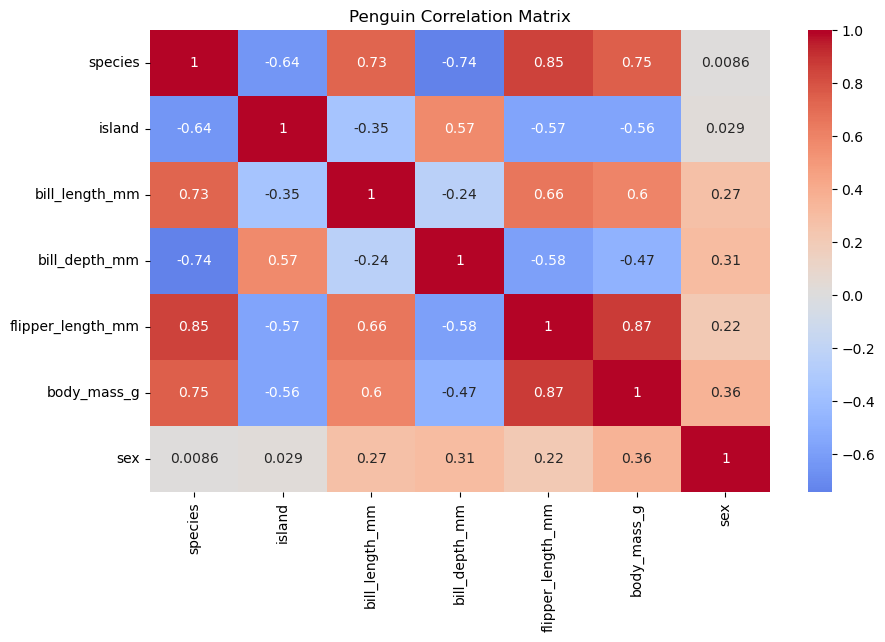

In [7]:
# TODO 3-5: 상관계수 행렬과 히트맵

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Penguin Correlation Matrix")
plt.show()

- species와 sex는 유의미한 연관성이 없다. 

### Linear Regression 모델 생성

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr_model = LinearRegression()